In [1]:
#Decision Tree

In [2]:
#Import Libraries

import pandas as pd

#import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree #Changed to Regressor 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.metrics import mean_squared_error, r2_score # Adjusted metrics for regression 
from sklearn.preprocessing import LabelEncoder

import numpy as np #Import numpy to use sqrt



In [3]:
#Load Dataset

df=pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\teen_phone_addiction_dataset.csv")



In [4]:
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [6]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [7]:
df.isnull().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [8]:
df=df.dropna()

In [13]:
df['target_col_name']= df['Addiction_Level']
print("\nTarget Column:", df['target_col_name'])


Target Column: 0       10.0
1       10.0
2        9.2
3        9.8
4        8.6
        ... 
2995     9.8
2996     5.5
2997     6.2
2998    10.0
2999     6.3
Name: target_col_name, Length: 3000, dtype: float64


In [16]:
print("\nTarget Variable value count:\n", df['target_col_name'].value_counts())
df['target_col_name']=df['target_col_name'].astype(int)


Target Variable value count:
 target_col_name
10.0    1524
9.9       50
9.6       46
8.0       45
7.8       45
        ... 
2.0        1
2.6        1
4.0        1
2.4        1
3.6        1
Name: count, Length: 80, dtype: int64


In [18]:
# #method 2

# #convert numeric addiction_Level into categories
# bins=[0,3,6,10] #ranges for low medium high
# labels=["Low", "Medium", "High"]
# df["Addiction_category"]=pd.cut(df["Addiction_Level"],bins=bins, labels=labels,includes_lowest=true)
# #set target column
# target_col="Addiction_Category"
# # encode categorical features

In [19]:
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level', 'target_col_name'],
      dtype='object')

In [20]:
cols=df.select_dtypes(include='object').columns
cols

Index(['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose'], dtype='object')

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])

In [23]:
df.corr()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level,target_col_name
ID,1.000000,-0.004587,-0.035674,-0.009726,0.012011,0.005384,-0.004700,0.018254,-0.013589,-0.041130,...,-0.037117,-0.004608,0.017989,0.014501,-0.000726,-0.000400,-0.019269,0.018583,-0.007263,-0.008126
Name,-0.004587,1.000000,-0.016291,-0.003517,0.019892,0.015464,-0.016684,-0.005477,-0.013337,0.007496,...,0.029197,-0.017901,-0.006883,-0.003888,-0.006905,0.021518,-0.018623,0.014761,-0.019186,-0.018978
Age,-0.035674,-0.016291,1.000000,-0.013583,-0.016589,-0.017654,0.040689,0.014725,0.023481,-0.020240,...,-0.008696,-0.003000,-0.005100,-0.008967,0.008372,0.009273,-0.003813,0.002801,0.031306,0.026876
Gender,-0.009726,-0.003517,-0.013583,1.000000,-0.006315,-0.005795,-0.020679,-0.008885,0.020561,-0.004449,...,-0.008985,0.023141,-0.005942,-0.045998,-0.056161,-0.001399,-0.014056,-0.010164,-0.031494,-0.028972
Location,0.012011,0.019892,-0.016589,-0.006315,1.000000,-0.013417,-0.009590,-0.008540,-0.018677,0.033795,...,0.012030,-0.004985,-0.005485,0.011244,0.001922,-0.005799,0.004673,-0.010639,0.008928,0.012758
School_Grade,0.005384,0.015464,-0.017654,-0.005795,-0.013417,1.000000,0.008075,0.026486,0.005392,-0.003166,...,-0.003153,-0.031940,-0.001775,0.036261,0.006082,-0.019496,-0.022698,0.006149,-0.006840,-0.004208
Daily_Usage_Hours,-0.004700,-0.016684,0.040689,-0.020679,-0.009590,0.008075,1.000000,0.016444,0.021345,-0.030383,...,0.004749,0.022841,-0.012620,-0.010371,0.014265,-0.019900,0.004427,0.019551,0.600771,0.611961
Sleep_Hours,0.018254,-0.005477,0.014725,-0.008885,-0.008540,0.026486,0.016444,1.000000,-0.000273,-0.017898,...,0.005198,0.026436,-0.018288,0.005798,-0.009756,-0.007392,-0.027040,-0.003670,-0.216681,-0.222390
Academic_Performance,-0.013589,-0.013337,0.023481,0.020561,-0.018677,0.005392,0.021345,-0.000273,1.000000,0.011815,...,-0.017102,-0.026136,0.036357,-0.033734,0.016377,-0.014884,-0.027859,0.014263,0.012264,0.013238
Social_Interactions,-0.041130,0.007496,-0.020240,-0.004449,0.033795,-0.003166,-0.030383,-0.017898,0.011815,1.000000,...,0.011992,-0.025440,0.002776,-0.004920,-0.008254,-0.013318,0.004239,-0.021410,-0.010631,-0.013507


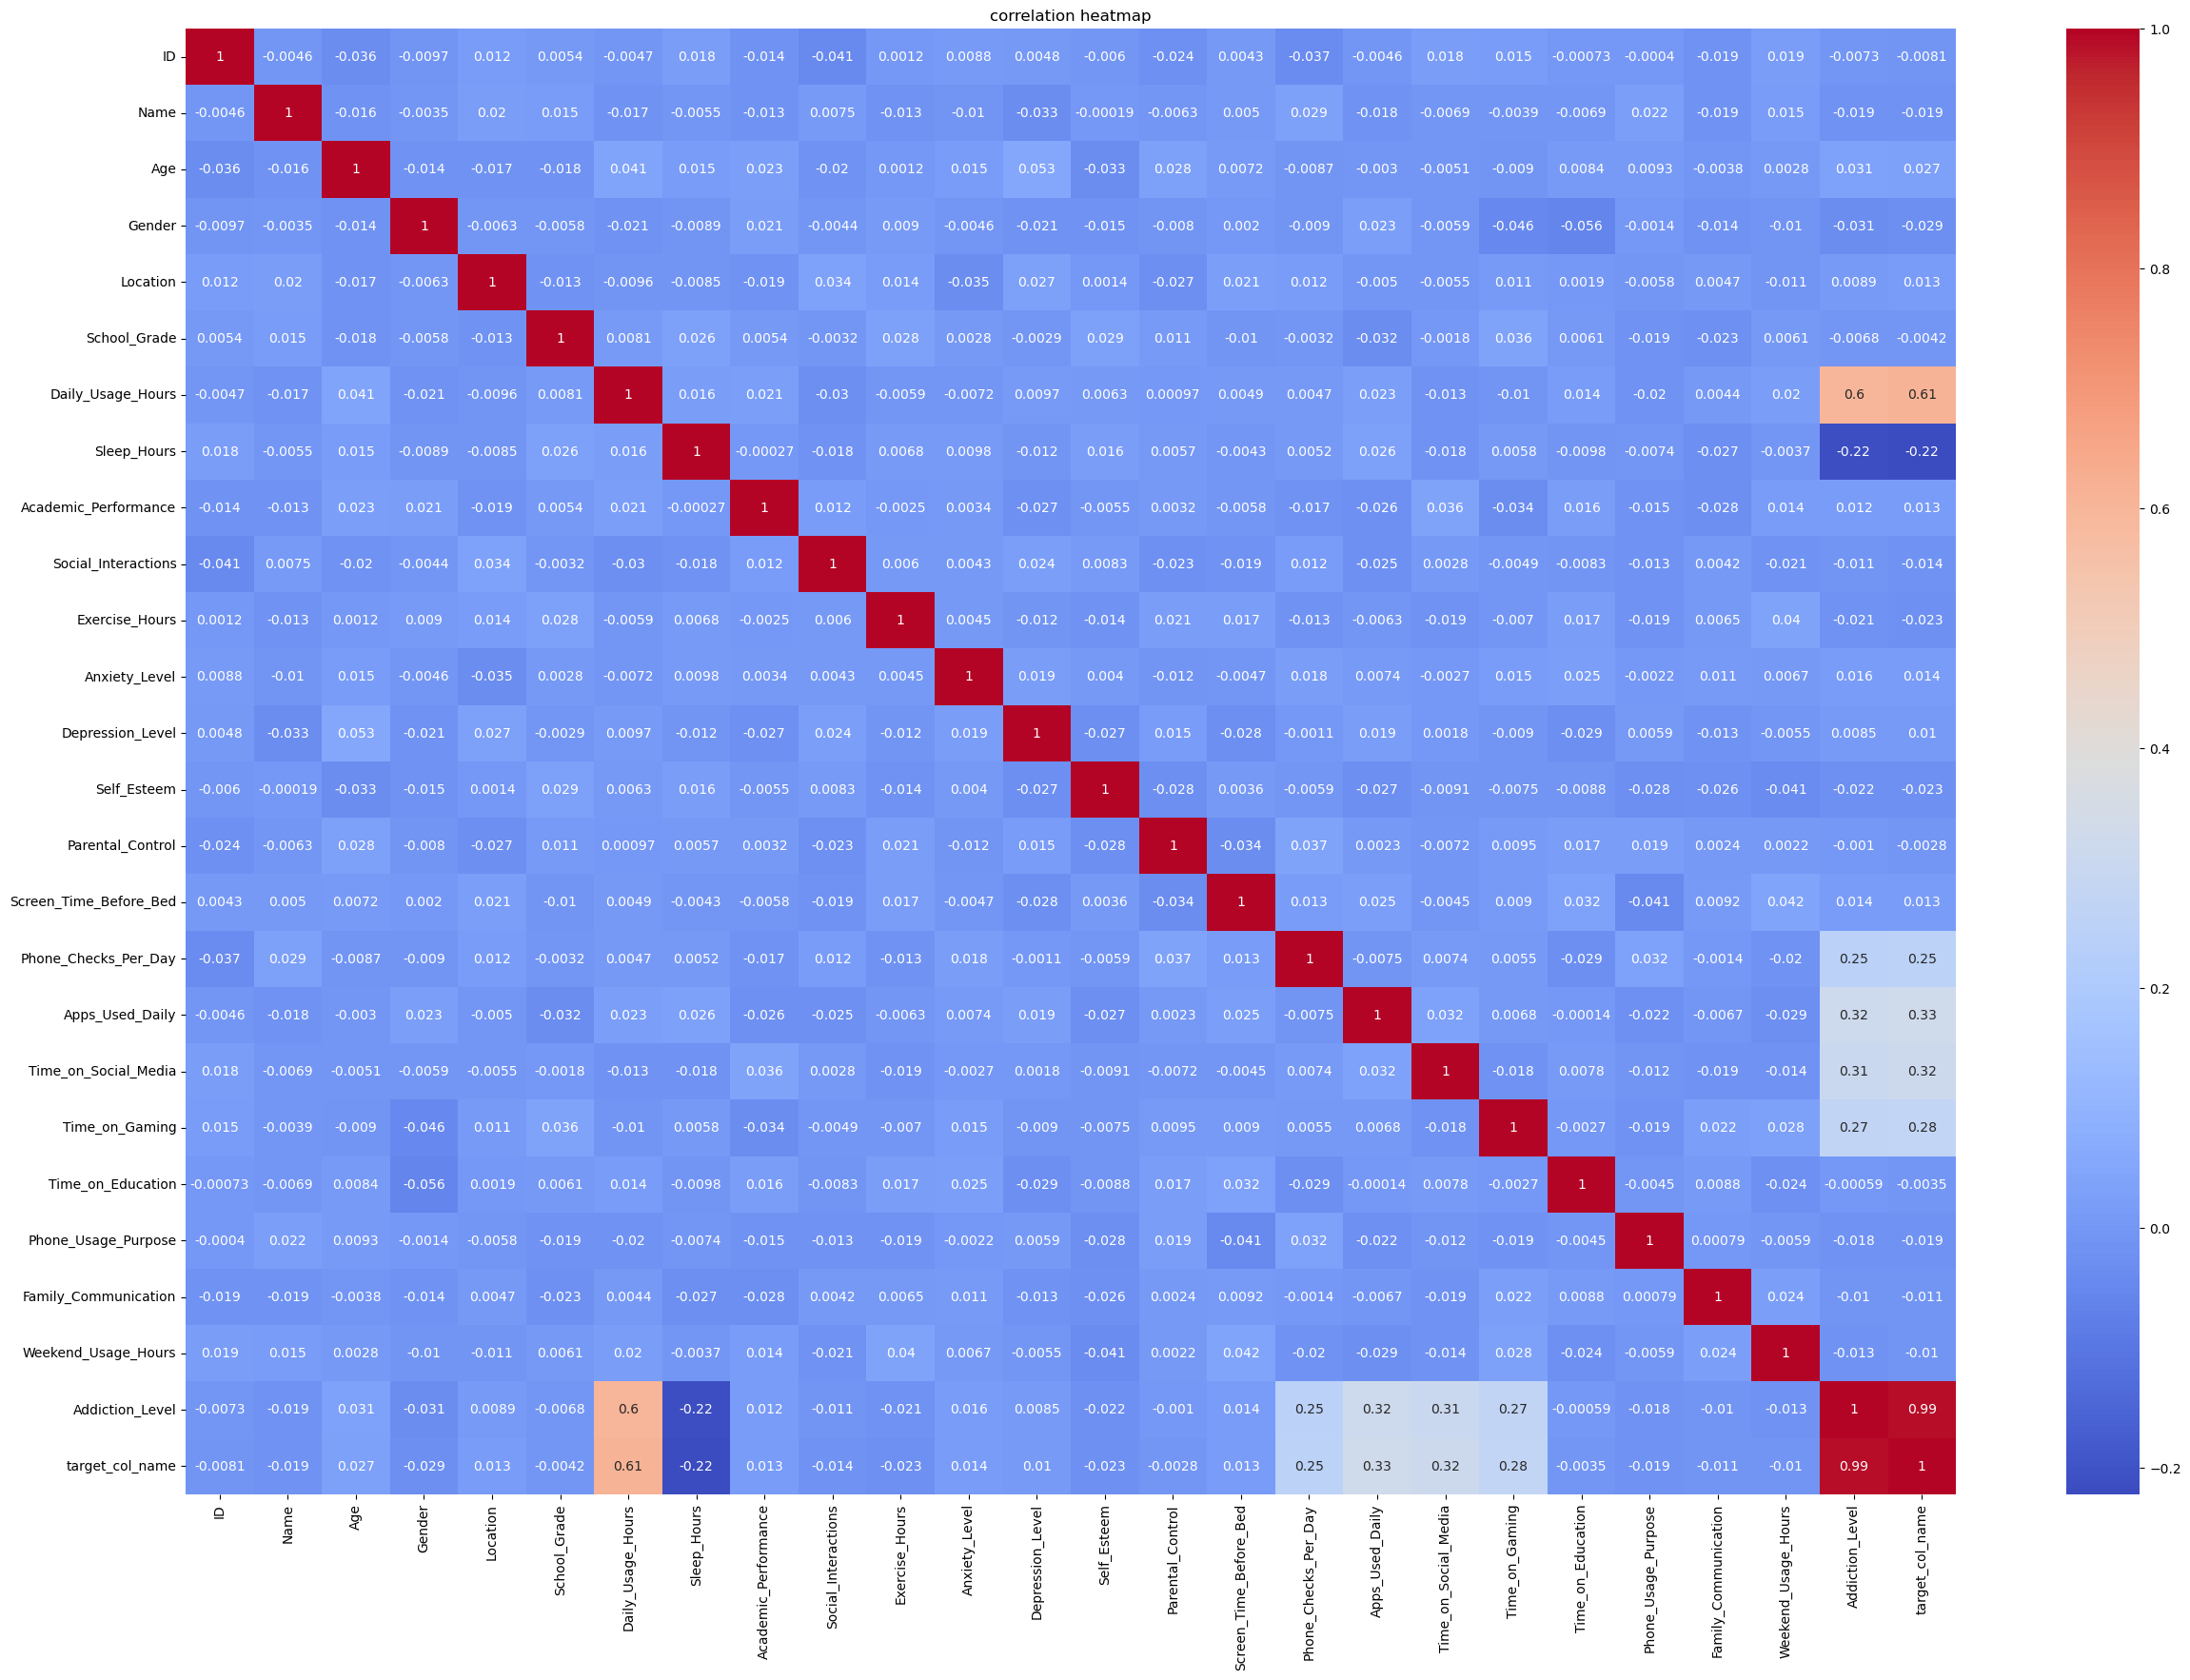

In [24]:
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [29]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

NameError: name 'DecisionTreeClassifier' is not defined

In [17]:
age = int(input("Enter your age: "))

if age >= 18:
    print("You are eligible to vote")
else:
    print("You are not eligible to vote")

Enter your age:  55


You are eligible to vote


In [28]:
lst = [1, 2, 2, 3, 4, 4, 5]

new_list = []

for i in lst:
    if i not in new_list:
        new_list.append(i)

print(new_list)

[1, 2, 3, 4, 5]
